# 유튜버 이탈 예측 시스템
## 전체 흐름
```
사용자 입력 (URL / channel_id / 채널명)
        ↓
   channel_id 추출
        ↓
  DB(CSV)에 있는가?
  ┌──── YES ────┐        ┌──── NO ────┐
  DB에서 피처 로드   yt-dlp로 실시간 수집
        └──────────┬──────────┘
              XGBoost 모델
                   ↓
         이탈 확률 + SHAP 주요 원인
```


## 0. 라이브러리 & 설정

In [1]:
from typing import Optional
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import re
import json
import subprocess
import joblib
import shap
warnings.filterwarnings("ignore")

from scipy.stats             import linregress
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing   import StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (classification_report, roc_auc_score,
                                      confusion_matrix, ConfusionMatrixDisplay,
                                      roc_curve)
from sklearn.calibration      import CalibratedClassifierCV
from xgboost                  import XGBClassifier

# 한글 폰트 설정 (환경에 맞게)
try:
    matplotlib.rcParams["font.family"] = "AppleGothic"   # Mac
except:
    try:
        matplotlib.rcParams["font.family"] = "Malgun Gothic"  # Windows
    except:
        pass
matplotlib.rcParams["axes.unicode_minus"] = False

RANDOM_STATE   = 42
CHURN_DAYS     = 180
DB_PATH        = "../../data/raw/filtered_dataset_wide.csv"   # ← 경로 확인 후 수정
LONG_PATH      = "../../data/raw/filtered_dataset_long.csv"
MODEL_SAVE_PATH = "churn_model.pkl"

print("라이브러리 로드 완료")


라이브러리 로드 완료


## 1. 데이터 로드 & 전처리

In [2]:
wide_df = pd.read_csv(DB_PATH)
long_df = pd.read_csv(LONG_PATH)

# 추가 점수 파일 (있으면 merge, 없으면 skip)
import os
score_files = {
    "view_volatility_df"    : ("../../data/raw/view_volatility_output.csv",   ["channel_id","volatility_prob"]),
    "upload_regularity_df"  : ("../../data/raw/upload_regularity_score.csv",  ["channel_id","regularity_score"]),
    "active_viewer_df"      : ("../../data/raw/active_viewer_score.csv",      ["channel_id","active_viewer_score","view_per_sub"]),
    "sensitive_keyword_df"  : ("../../data/raw/sensitive_keyword_score.csv",  ["channel_id","sensitive_score"]),
}
score_dfs = {}
for name, (path, cols) in score_files.items():
    if os.path.exists(path):
        score_dfs[name] = pd.read_csv(path)[cols]
        print(f"  로드 완료: {path}")
    else:
        print(f"  파일 없음 (skip): {path}")

print(f"\nwide shape: {wide_df.shape} | long shape: {long_df.shape}")


  로드 완료: ../../data/raw/view_volatility_output.csv
  로드 완료: ../../data/raw/upload_regularity_score.csv
  로드 완료: ../../data/raw/active_viewer_score.csv
  로드 완료: ../../data/raw/sensitive_keyword_score.csv

wide shape: (3336, 22) | long shape: (166449, 18)


In [3]:
# 이탈 라벨 생성
wide_df["is_churned"] = (wide_df["days_since_last_upload"] >= CHURN_DAYS).astype(int)
print(f"이탈 분포:\n{wide_df['is_churned'].value_counts()}")
print(f"이탈률: {wide_df['is_churned'].mean():.2%}")


이탈 분포:
is_churned
0    2641
1     695
Name: count, dtype: int64
이탈률: 20.83%


## 2. 피처 엔지니어링

In [4]:
# wide 파생 피처
wide_df["view_cv"]              = wide_df["std_view_count"] / (wide_df["avg_view_count"] + 1e-9)
wide_df["view_per_subscriber"]  = wide_df["avg_view_count"] / (wide_df["subscriber_count"] + 1e-9)
wide_df["avg_shorts_view"]      = wide_df["avg_shorts_view"].fillna(0)
wide_df["avg_normal_view"]      = wide_df["avg_normal_view"].fillna(0)
wide_df["avg_engagement_rate"]  = wide_df["avg_engagement_rate"].clip(0, 1)

# long → 채널 단위 시계열 피처
long_df["published_at"] = pd.to_datetime(long_df["published_at"], utc=True, errors="coerce")
NOW = long_df["published_at"].max()

def extract_long_features(group):
    g = group.sort_values("published_at")
    g["ym"] = g["published_at"].dt.to_period("M")
    monthly = g.groupby("ym").size().reset_index(name="cnt")
    slope   = linregress(range(len(monthly)), monthly["cnt"])[0] if len(monthly) >= 3 else np.nan
    t3      = NOW - pd.Timedelta(days=90)
    recent_3m = (g["published_at"] >= t3).sum()
    views   = g["view_count"].dropna().tolist()
    view_ratio = round(np.mean(views[-10:]) / (np.mean(views) + 1e-9), 4) if len(views) >= 10 else np.nan
    dates   = g["published_at"].dropna().tolist()
    days_last2 = (dates[-1] - dates[-2]).days if len(dates) >= 2 else np.nan
    return pd.Series({
        "upload_slope"          : slope,
        "recent_3m_upload_count": int(recent_3m),
        "recent_view_ratio"     : view_ratio,
        "days_between_last2"    : days_last2,
    })

long_features = long_df.groupby("channel_id").apply(
    extract_long_features, include_groups=False
).reset_index()

print("long 피처 추출 완료:", long_features.shape)


long 피처 추출 완료: (3336, 5)


In [5]:
# 전체 피처 병합
from functools import reduce

dfs = [wide_df, long_features] + list(score_dfs.values())
merged_df = reduce(
    lambda l, r: pd.merge(l, r, on="channel_id", how="left"), dfs
)

# 피처 목록 정의
WIDE_FEATURES = [
    "subscriber_count", "view_count", "total_video_count",
    "avg_upload_interval_days", "std_upload_interval_days",
    "max_gap_days", "hiatus_count_30d",
    "avg_view_count", "std_view_count",
    "avg_like_count", "avg_comment_count", "avg_engagement_rate",
    "shorts_ratio", "avg_shorts_view", "avg_normal_view",
    "view_per_subscriber", "view_cv",
]
LONG_FEATURES = ["upload_slope", "recent_view_ratio", "days_between_last2"]
SCORE_FEATURES = [f for f in ["volatility_prob","regularity_score","active_viewer_score","sensitive_score"]
                  if f in merged_df.columns]

ALL_FEATURES = WIDE_FEATURES + LONG_FEATURES + SCORE_FEATURES

# 결측치 처리
for feat in ALL_FEATURES:
    merged_df[feat] = merged_df[feat].fillna(merged_df[feat].median())

X = merged_df[ALL_FEATURES].copy()
y = merged_df["is_churned"].copy()

print(f"최종 피처 수: {len(ALL_FEATURES)}")
print(f"샘플 수    : {len(X)}")
print(f"ALL_FEATURES: {ALL_FEATURES}")


최종 피처 수: 24
샘플 수    : 3336
ALL_FEATURES: ['subscriber_count', 'view_count', 'total_video_count', 'avg_upload_interval_days', 'std_upload_interval_days', 'max_gap_days', 'hiatus_count_30d', 'avg_view_count', 'std_view_count', 'avg_like_count', 'avg_comment_count', 'avg_engagement_rate', 'shorts_ratio', 'avg_shorts_view', 'avg_normal_view', 'view_per_subscriber', 'view_cv', 'upload_slope', 'recent_view_ratio', 'days_between_last2', 'volatility_prob', 'regularity_score', 'active_viewer_score', 'sensitive_score']


## 3. 모델 학습 — XGBoost Classifier

> **이전 노트북 버그 수정**: `RandomForestRegressor`로 분류를 시도해
> `classification_report` 에러가 발생했습니다.
> **XGBClassifier** 로 통일하고 `predict_proba`로 이탈 확률을 출력합니다.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight,   # 클래스 불균형 보정
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE,
    verbosity        = 0,
)

model.fit(X_train, y_train)
print("학습 완료")


학습 완료


In [7]:
# 평가
y_pred      = model.predict(X_test)
y_prob      = model.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_prob)

print(f"AUC-ROC: {auc:.4f}")
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["활성(0)","이탈(1)"]))


AUC-ROC: 0.8353

=== Classification Report ===
              precision    recall  f1-score   support

       활성(0)       0.90      0.84      0.86       529
       이탈(1)       0.50      0.63      0.56       139

    accuracy                           0.79       668
   macro avg       0.70      0.73      0.71       668
weighted avg       0.81      0.79      0.80       668



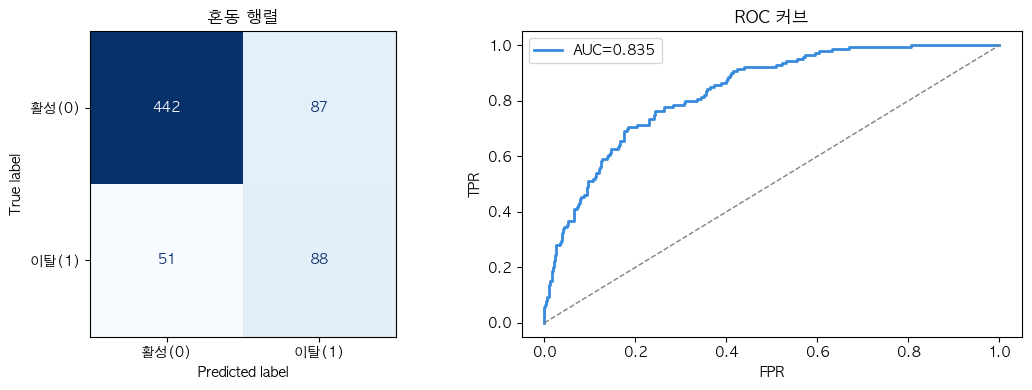

In [8]:
# 혼동행렬 + ROC 커브
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["활성(0)","이탈(1)"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("혼동 행렬")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#378ADD", lw=2, label=f"AUC={auc:.3f}")
axes[1].plot([0,1],[0,1],"--", color="gray", lw=1)
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].set_title("ROC 커브"); axes[1].legend()

plt.tight_layout(); plt.show()


## 4. SHAP 설정 (원인 분석용)

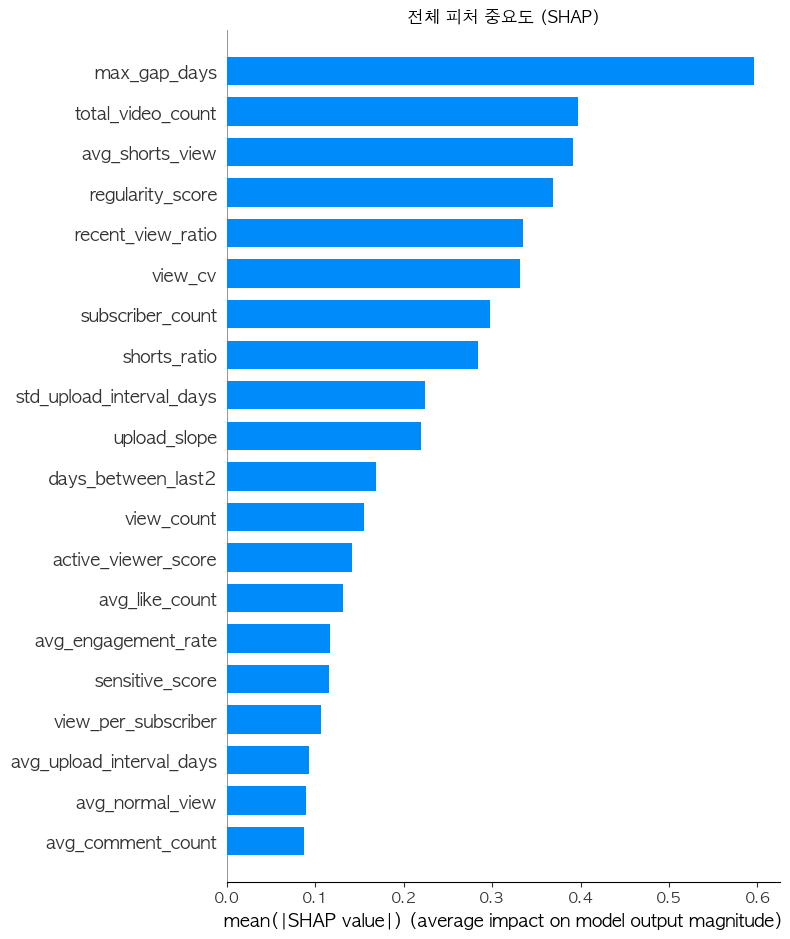

In [9]:
explainer = shap.TreeExplainer(model)
shap_values_all = explainer.shap_values(X)

# 전체 피처 중요도 시각화
shap.summary_plot(shap_values_all, X, plot_type="bar", show=False)
plt.title("전체 피처 중요도 (SHAP)")
plt.tight_layout()
plt.show()


## 5. 모델 저장

In [10]:
joblib.dump({
    "model"       : model,
    "explainer"   : explainer,
    "features"    : ALL_FEATURES,
    "feature_medians": {f: float(merged_df[f].median()) for f in ALL_FEATURES},
}, MODEL_SAVE_PATH)

print(f"모델 저장 완료: {MODEL_SAVE_PATH}")
print(f"저장 항목: model / explainer / features({len(ALL_FEATURES)}개) / feature_medians")


모델 저장 완료: churn_model.pkl
저장 항목: model / explainer / features(24개) / feature_medians


## 6. 채널 검색 & 이탈 예측 함수

### 흐름
```
입력 (URL / channel_id / 채널명)
        ↓  extract_channel_id()
   channel_id
        ↓  predict_churn()
  ┌── DB에 있음? ──┐
  CSV에서 피처 로드  yt-dlp로 실시간 수집 → 피처 계산
        └────────────┘
         XGBoost 예측
        이탈 확률 + SHAP 상위 3개 원인 출력
```


In [11]:
# ── Step 1. 입력 → channel_id 추출 ──────────────────────────────────────────

def extract_channel_id(query: str) -> Optional[str]:
    """URL / @handle / channel_id / 채널명 → channel_id 반환"""
    query = query.strip()

    # 1) 직접 channel_id 형식 (UC로 시작하는 24자리)
    if re.match(r'^UC[a-zA-Z0-9_-]{22}$', query):
        return query

    # 2) URL에서 channel_id 추출
    #    https://www.youtube.com/channel/UCxxxxxxxx
    m = re.search(r'youtube\.com/channel/(UC[a-zA-Z0-9_-]{22})', query)
    if m:
        return m.group(1)

    # 3) @handle 또는 /c/ /user/ 형식 → yt-dlp로 resolve
    if "youtube.com" in query or query.startswith("@"):
        url = query if "youtube.com" in query else f"https://www.youtube.com/{query}"
        try:
            result = subprocess.run(
                ["yt-dlp", "--print", "channel_id", "--playlist-items", "0", url],
                capture_output=True, text=True, timeout=15
            )
            cid = result.stdout.strip()
            if re.match(r'^UC[a-zA-Z0-9_-]{22}$', cid):
                return cid
        except Exception as e:
            print(f"[yt-dlp resolve 실패] {e}")
            return None

    # 4) 채널명 → DB에서 검색
    match = merged_df[merged_df["title"].str.contains(query, na=False, regex=False)]
    if len(match) > 0:
        print(f"  DB에서 '{query}' 매칭: {match.iloc[0]['title']} ({match.iloc[0]['channel_id']})")
        return match.iloc[0]["channel_id"]

    return None


In [12]:
# ── Step 2. DB 조회 또는 yt-dlp 수집 ────────────────────────────────────────

def fetch_features_from_db(channel_id: str) -> Optional[pd.DataFrame]:
    """DB(merged_df)에서 피처 행 반환"""
    row = merged_df[merged_df["channel_id"] == channel_id]
    if len(row) == 0:
        return None
    return row[ALL_FEATURES].copy()


def fetch_features_from_ytdlp(channel_id: str) -> Optional[pd.DataFrame]:
    """yt-dlp로 채널 최근 50개 영상 수집 → 피처 계산"""
    url = f"https://www.youtube.com/channel/{channel_id}/videos"
    print(f"  [yt-dlp] 수집 시작: {url}")
    try:
        result = subprocess.run(
            [
                "yt-dlp",
                "--dump-json",
                "--playlist-end", "50",
                "--no-warnings",
                url,
            ],
            capture_output=True, text=True, timeout=120,
        )
        lines = [l for l in result.stdout.strip().split("\n") if l]
        if not lines:
            print("  [yt-dlp] 수집된 영상 없음")
            return None

        records = [json.loads(l) for l in lines]
        df_raw  = pd.DataFrame(records)

        # 필요한 컬럼만 추출
        df_v = pd.DataFrame({
            "channel_id"   : channel_id,
            "published_at" : pd.to_datetime(df_raw.get("upload_date", pd.Series()), format="%Y%m%d", errors="coerce"),
            "view_count"   : pd.to_numeric(df_raw.get("view_count",   pd.Series()), errors="coerce"),
            "like_count"   : pd.to_numeric(df_raw.get("like_count",   pd.Series()), errors="coerce"),
            "comment_count": pd.to_numeric(df_raw.get("comment_count",pd.Series()), errors="coerce"),
            "duration_sec" : pd.to_numeric(df_raw.get("duration",     pd.Series()), errors="coerce"),
            "is_shorts"    : df_raw.get("duration", pd.Series(0)).apply(lambda d: int(d) <= 60 if pd.notna(d) else False),
        })

        # wide 피처 계산
        ch_info  = records[0]
        # 채널명: channel > uploader > uploader_id 순으로 우선 사용
        channel_name_raw = (ch_info.get("channel")
                           or ch_info.get("uploader")
                           or ch_info.get("uploader_id")
                           or "알 수 없음")
        sub_cnt  = ch_info.get("channel_follower_count", 0) or 0
        tot_vids = ch_info.get("playlist_count", len(records))

        dates    = df_v["published_at"].dropna().sort_values().tolist()
        intervals= [(dates[i+1]-dates[i]).days for i in range(len(dates)-1)] if len(dates)>1 else [0]
        NOW_local= pd.Timestamp.now(tz="UTC")

        # long 피처
        df_v["published_at"] = df_v["published_at"].dt.tz_localize("UTC")
        df_v_sorted = df_v.sort_values("published_at")
        df_v_sorted["ym"] = df_v_sorted["published_at"].dt.to_period("M")
        monthly = df_v_sorted.groupby("ym").size().reset_index(name="cnt")
        slope_val = linregress(range(len(monthly)), monthly["cnt"])[0] if len(monthly)>=3 else np.nan
        t3    = NOW_local - pd.Timedelta(days=90)
        r3m   = (df_v_sorted["published_at"]>=t3).sum()
        views = df_v["view_count"].dropna().tolist()
        vr    = round(np.mean(views[-10:])/(np.mean(views)+1e-9),4) if len(views)>=10 else np.nan
        d_last2 = (dates[-1]-dates[-2]).days if len(dates)>=2 else np.nan

        shorts  = df_v[df_v["is_shorts"]==True]
        normal  = df_v[df_v["is_shorts"]==False]

        feat = {
            "subscriber_count"         : sub_cnt,
            "view_count"               : df_v["view_count"].sum(),
            "total_video_count"        : tot_vids,
            "avg_upload_interval_days" : np.mean(intervals),
            "std_upload_interval_days" : np.std(intervals),
            "max_gap_days"             : max(intervals),
            "hiatus_count_30d"         : sum(1 for d in intervals if d>=30),
            "avg_view_count"           : df_v["view_count"].mean(),
            "std_view_count"           : df_v["view_count"].std(),
            "avg_like_count"           : df_v["like_count"].mean(),
            "avg_comment_count"        : df_v["comment_count"].mean(),
            "avg_engagement_rate"      : min(((df_v["like_count"]+df_v["comment_count"])/(df_v["view_count"]+1e-9)).mean(),1),
            "shorts_ratio"             : len(shorts)/(len(df_v)+1e-9),
            "avg_shorts_view"          : shorts["view_count"].mean() if len(shorts)>0 else 0,
            "avg_normal_view"          : normal["view_count"].mean() if len(normal)>0 else 0,
            "view_per_subscriber"      : df_v["view_count"].mean()/(sub_cnt+1e-9),
            "view_cv"                  : df_v["view_count"].std()/(df_v["view_count"].mean()+1e-9),
            "upload_slope"             : slope_val,
            "recent_view_ratio"        : vr,
            "days_between_last2"       : d_last2,
        }

        # score 피처는 DB에 없으므로 중앙값으로 대체
        model_meta = joblib.load(MODEL_SAVE_PATH)
        for f in SCORE_FEATURES:
            feat[f] = model_meta["feature_medians"].get(f, 0)

        feat_df = pd.DataFrame([feat])[ALL_FEATURES]
        feat_df = feat_df.fillna(feat_df.median())
        feat_df["channel_name"] = channel_name_raw   # 채널명 전달용
        return feat_df

    except Exception as e:
        print(f"  [yt-dlp 오류] {e}")
        return None


In [15]:
# ── Step 3. 예측 + SHAP 원인 분석 ───────────────────────────────────────────

FEATURE_KO = {
    "subscriber_count"         : "구독자 수",
    "view_count"               : "채널 누적 조회수",
    "total_video_count"        : "전체 영상 수",
    "avg_upload_interval_days" : "평균 업로드 간격(일)",
    "std_upload_interval_days" : "업로드 간격 불규칙성",
    "max_gap_days"             : "최대 공백 기간(일)",
    "hiatus_count_30d"         : "30일+ 공백 횟수",
    "avg_view_count"           : "평균 조회수",
    "std_view_count"           : "조회수 변동성",
    "avg_like_count"           : "평균 좋아요 수",
    "avg_comment_count"        : "평균 댓글 수",
    "avg_engagement_rate"      : "평균 참여율",
    "shorts_ratio"             : "Shorts 비율",
    "avg_shorts_view"          : "Shorts 평균 조회수",
    "avg_normal_view"          : "일반 영상 평균 조회수",
    "view_per_subscriber"      : "구독자 대비 조회수",
    "view_cv"                  : "조회수 변동계수",
    "upload_slope"             : "업로드 추세(기울기)",
    "recent_view_ratio"        : "최근 조회수 추세",
    "days_between_last2"       : "마지막 두 영상 간격",
    "volatility_prob"          : "조회수 변동성 점수",
    "regularity_score"         : "업로드 규칙성 점수",
    "active_viewer_score"      : "활성 시청자 점수",
    "sensitive_score"          : "민감 키워드 점수",
}

def predict_churn(query: str, top_n: int = 3):
    """
    query: URL / channel_id / @handle / 채널명
    top_n: 출력할 주요 원인 수
    """
    print(f"{'='*55}")
    print(f"  검색어: {query}")
    print(f"{'='*55}")

    # 1) channel_id 추출
    channel_id = extract_channel_id(query)
    if not channel_id:
        print(f"  [오류] channel_id를 추출할 수 없습니다: {query}")
        return
    print(f"  channel_id: {channel_id}")

    # 2) DB 조회 → 없으면 yt-dlp 수집
    feat_df = fetch_features_from_db(channel_id)
    source  = "DB"
    if feat_df is None:
        print(f"  DB에 없음 → yt-dlp로 실시간 수집 중...")
        feat_df = fetch_features_from_ytdlp(channel_id)
        source  = "yt-dlp"
    if feat_df is None:
        print("  [오류] 피처 수집 실패")
        return
    print(f"  데이터 출처: {source}")

    # 3) 채널명 추출 (모델 투입 전에 분리)
    channel_name = "알 수 없음"

    # yt-dlp 수집 결과에 channel_name 컬럼이 있으면 꺼내고 제거
    if "channel_name" in feat_df.columns:
        channel_name = str(feat_df["channel_name"].values[0])
        feat_df = feat_df.drop(columns=["channel_name"])  # 모델 피처에서 반드시 제거

    # DB에 있는 채널이면 title 컬럼으로 덮어씀 (더 정확)
    row = merged_df[merged_df["channel_id"] == channel_id]
    if len(row) > 0:
        channel_name = row.iloc[0]["title"]

    # 4) 모델 예측 (channel_name 제거 후)
    churn_prob = model.predict_proba(feat_df)[0][1]
    churn_pred = int(churn_prob >= 0.5)

    risk_level = (
        "🔴 고위험" if churn_prob >= 0.7 else
        "🟡 주의"   if churn_prob >= 0.4 else
        "🟢 안전"
    )

    print(f"채널명     : {channel_name}")
    print(f"  이탈 확률  : {churn_prob:.1%}")
    print(f"  예측 결과  : {'이탈 위험' if churn_pred else '활동 유지'}")
    print(f"  위험 등급  : {risk_level}")

    # 5) SHAP 원인 분석
    sv     = explainer.shap_values(feat_df)
    shap_s = pd.Series(sv[0], index=ALL_FEATURES)
    top    = shap_s.abs().sort_values(ascending=False).head(top_n)

    print(f"[주요 원인 Top {top_n}]")
    print(f"  {'피처':<28} {'실제값':>12}  {'영향':<18} 방향")
    print(f"  {'-'*70}")
    for feat, _ in top.items():
        sv_val    = shap_s[feat]
        feat_val  = feat_df[feat].values[0]
        direction = "→ 이탈 위험 ↑" if sv_val > 0 else "→ 이탈 위험 ↓"
        ko_name   = FEATURE_KO.get(feat, feat)
        print(f"  {ko_name:<28} {feat_val:>12.4f}  {sv_val:>+.4f}          {direction}")

    # 6) SHAP 시각화
    fig, ax = plt.subplots(figsize=(8, 4))
    colors  = ["#D85A30" if shap_s[f] > 0 else "#5DCAA5" for f in top.index]
    ko_labels = [FEATURE_KO.get(f, f) for f in top.index]
    ax.barh(ko_labels[::-1], shap_s[top.index].values[::-1], color=colors[::-1], edgecolor="none")
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(f"{channel_name}이탈 확률: {churn_prob:.1%}  |  {risk_level}", fontsize=11)
    ax.set_xlabel("SHAP value (양수=이탈 위험 증가, 음수=이탈 위험 감소)")
    plt.tight_layout()
    plt.show()

    return {
        "channel_id"  : channel_id,
        "channel_name": channel_name,
        "churn_prob"  : round(churn_prob, 4),
        "risk_level"  : risk_level,
        "top_reasons" : {FEATURE_KO.get(f,f): round(shap_s[f],4) for f in top.index},
    }


## 7. 실행 예시

  검색어: https://www.youtube.com/channel/UCNhofiqfw5nl-NeDJkXtPvw
  channel_id: UCNhofiqfw5nl-NeDJkXtPvw
  DB에 없음 → yt-dlp로 실시간 수집 중...
  [yt-dlp] 수집 시작: https://www.youtube.com/channel/UCNhofiqfw5nl-NeDJkXtPvw/videos
  데이터 출처: yt-dlp
채널명     : 빠니보틀 Pani Bottle
  이탈 확률  : 16.5%
  예측 결과  : 활동 유지
  위험 등급  : 🟢 안전
[주요 원인 Top 3]
  피처                                    실제값  영향                 방향
  ----------------------------------------------------------------------
  조회수 변동계수                           0.3105  -1.5030          → 이탈 위험 ↓
  구독자 수                        2570000.0000  -0.6008          → 이탈 위험 ↓
  최근 조회수 추세                          1.1350  +0.5506          → 이탈 위험 ↑


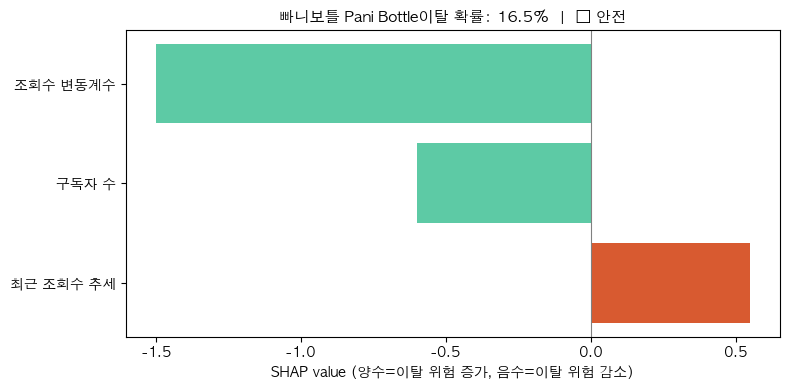

In [17]:
# ── 사용법 ────────────────────────────────────────────────────────────────────
# DB에 있는 채널 (빠름)
#result = predict_churn("2M (투엠) ENT")

# channel_id 직접 입력
# result = predict_churn("UC0_yHLyKYYvG4bzylDs3pwA")

# YouTube URL (yt-dlp로 channel_id 추출 후 DB 조회)
result = predict_churn("https://www.youtube.com/channel/UCNhofiqfw5nl-NeDJkXtPvw")

# @handle (yt-dlp로 실시간 수집)
# result = predict_churn("@channelhandle")

# DB에 없는 채널 → yt-dlp 자동 수집
# result = predict_churn("https://www.youtube.com/@example")


  검색어: 2M (투엠) ENT
  DB에서 '2M (투엠) ENT' 매칭: 2M (투엠) ENT (UC0_yHLyKYYvG4bzylDs3pwA)
  channel_id: UC0_yHLyKYYvG4bzylDs3pwA
  데이터 출처: DB
채널명     : 2M (투엠) ENT
  이탈 확률  : 18.1%
  예측 결과  : 활동 유지
  위험 등급  : 🟢 안전
[주요 원인 Top 3]
  피처                                    실제값  영향                 방향
  ----------------------------------------------------------------------
  최근 조회수 추세                          0.3145  -0.5404          → 이탈 위험 ↓
  최대 공백 기간(일)                        5.0000  -0.4908          → 이탈 위험 ↓
  구독자 수                         100000.0000  +0.3990          → 이탈 위험 ↑


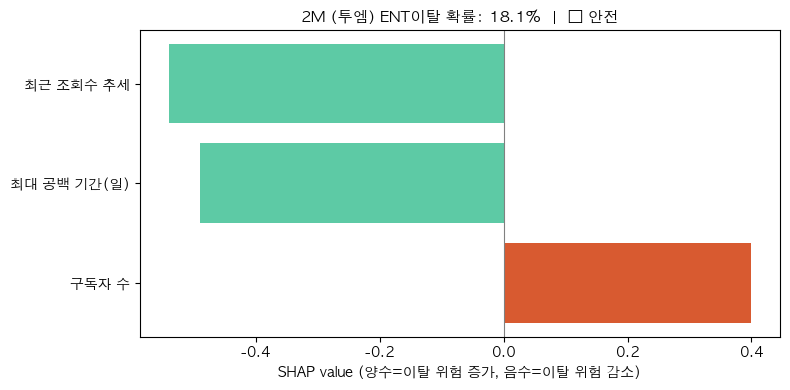

  검색어: 심킹 (ABYSSKIMG)
  DB에서 '심킹 (ABYSSKIMG)' 매칭: 심킹 (ABYSSKIMG) (UCDYdwDXhbVZXkdV6kZn-0IQ)
  channel_id: UCDYdwDXhbVZXkdV6kZn-0IQ
  데이터 출처: DB
채널명     : 심킹 (ABYSSKIMG)
  이탈 확률  : 95.5%
  예측 결과  : 이탈 위험
  위험 등급  : 🔴 고위험
[주요 원인 Top 3]
  피처                                    실제값  영향                 방향
  ----------------------------------------------------------------------
  최대 공백 기간(일)                      360.0000  +0.9248          → 이탈 위험 ↑
  Shorts 평균 조회수                   1549.6700  +0.6020          → 이탈 위험 ↑
  전체 영상 수                          112.0000  +0.5512          → 이탈 위험 ↑


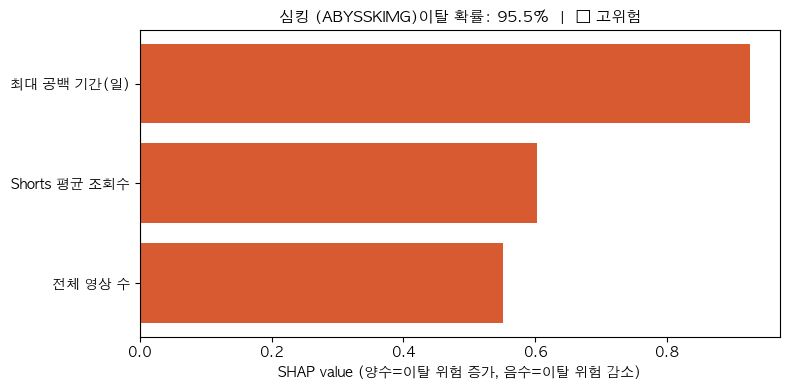

  검색어: DC튜브
  DB에서 'DC튜브' 매칭: DC튜브 (UCJQDi71H00IXCQbxAtFem3Q)
  channel_id: UCJQDi71H00IXCQbxAtFem3Q
  데이터 출처: DB
채널명     : DC튜브
  이탈 확률  : 12.8%
  예측 결과  : 활동 유지
  위험 등급  : 🟢 안전
[주요 원인 Top 3]
  피처                                    실제값  영향                 방향
  ----------------------------------------------------------------------
  전체 영상 수                         2043.0000  -0.6934          → 이탈 위험 ↓
  최근 조회수 추세                          0.5150  -0.5024          → 이탈 위험 ↓
  구독자 수                         100000.0000  +0.4776          → 이탈 위험 ↑


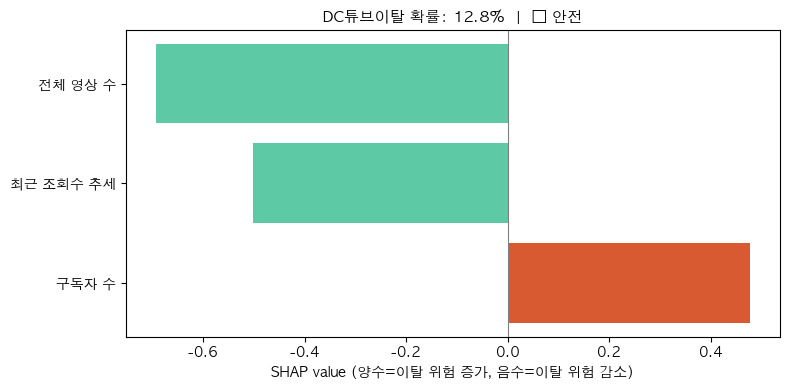


=== 일괄 예측 결과 ===
  channel_name  churn_prob risk_level
심킹 (ABYSSKIMG)      0.9554      🔴 고위험
   2M (투엠) ENT      0.1807       🟢 안전
          DC튜브      0.1284       🟢 안전


In [18]:
# 여러 채널 일괄 예측
channels = [
    "2M (투엠) ENT",
    "심킹 (ABYSSKIMG)",
    "DC튜브",
]

results = []
for ch in channels:
    r = predict_churn(ch)
    if r:
        results.append(r)

# 결과 테이블
if results:
    res_df = pd.DataFrame(results)[["channel_name","churn_prob","risk_level"]]
    res_df = res_df.sort_values("churn_prob", ascending=False)
    print("\n=== 일괄 예측 결과 ===")
    print(res_df.to_string(index=False))
